# Cone-Cluster Label Assignment Experiment

## Overview

This notebook implements a new data distribution with **c+1 cone clusters** on the unit sphere $S^{m-1}$. The first $c$ clusters are **feature clusters** $F_i$, while the $(c+1)$-th cluster is a **noise cluster**. Each example $x$ consists of $J$ patches. One random patch is drawn from a feature cluster and the remaining patches are drawn from the noise cluster.

We compare two label assignment strategies:

1. **Signal-based labels**: If the signal patch is drawn from $F_i$, the label is $i$.
2. **Random labels**: Labels are sampled uniformly at random from $\{1,\dots,c\}$, independent of the signal.

We train **one model only**: a **vanilla single-layer CNN with GAP** and **logistic (cross-entropy) loss**.

### Hypotheses
- The CNN can fit both signal-based and random labels on the training set.
- For signal-based labels, generalization should be meaningful (test accuracy/loss).
- For random labels, we only track training performance.

### Representation Learning Analysis (Part 3)
We analyze learned representations for the **signal-based dataset**. We **skip label-output alignment analysis**, as requested.



## 1. Setup and Configuration

We use PyTorch and standard scientific Python libraries. The code supports Apple Silicon (MPS), CUDA, or CPU.


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from typing import Tuple, Dict
import warnings

warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device selection
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
if device.type == 'mps':
    print("✓ Apple Silicon GPU (MPS) detected - Training will be much faster!")


Using device: mps
✓ Apple Silicon GPU (MPS) detected - Training will be much faster!


### Experiment Configuration

All hyperparameters are centralized here for clarity and reproducibility.


In [10]:
# Data parameters
DATA_CONFIG = {
    'm': 10,               # Patch dimension
    'J': 50,               # Number of patches
    'c': 5,                # Number of feature clusters
    'sigma': 0.1,          # Noise scale for cone clusters
    'n_train': 200,        # Training samples
    'n_test': 3000,        # Test samples (only used for signal-based labels)
}

# Model parameters
MODEL_CONFIG = {
    'K': 400,              # Number of shared filters
    'lr': 0.2,             # Learning rate
}

# Training parameters
TRAIN_CONFIG = {
    'epochs': 10000,
    'batch_size': None,    # None = full batch
    'weight_decay': 0.0,
    'grad_clip': 50.0,
    'print_every': 100,
}

print("Configuration Summary")
print(f"Patch dimension m: {DATA_CONFIG['m']}")
print(f"Number of patches J: {DATA_CONFIG['J']}")
print(f"Number of feature clusters c: {DATA_CONFIG['c']}")
print(f"Cone noise sigma: {DATA_CONFIG['sigma']}")
print(f"Training samples: {DATA_CONFIG['n_train']}")
print(f"Test samples: {DATA_CONFIG['n_test']}")


Configuration Summary
Patch dimension m: 10
Number of patches J: 50
Number of feature clusters c: 5
Cone noise sigma: 0.1
Training samples: 200
Test samples: 3000


## 2. Data Generation: Cone Clusters on $S^{m-1}$

We sample $c+1$ cluster centers $\{u_1, \dots, u_{c+1}\}$ uniformly on the unit sphere. For cluster $i$:

$$
\tilde{v} \sim \mathcal{N}(u_i, \sigma^2 I), \quad v = \frac{\tilde{v}}{\|\tilde{v}\|}.
$$

- Clusters $1..c$ are **feature clusters** $F_i$.
- Cluster $c+1$ is the **noise cluster**.

Each example has $J$ patches:
- One random patch is sampled from a random feature cluster $F_i$.
- All other patches are sampled from the noise cluster.


In [5]:
def sample_unit_vectors(num_vecs: int, dim: int) -> np.ndarray:
    """Sample unit vectors uniformly from the sphere."""
    vecs = np.random.randn(num_vecs, dim)
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
    return vecs


def sample_from_cone(center: np.ndarray, sigma: float, n: int) -> np.ndarray:
    """Sample n points from a cone cluster around a center on the sphere."""
    noise = np.random.randn(n, center.shape[0]) * sigma
    v = center[None, :] + noise
    v /= np.linalg.norm(v, axis=1, keepdims=True)
    return v


def generate_example(
    J: int,
    m: int,
    centers: np.ndarray,
    sigma: float,
    c: int,
    label_mode: str,
) -> Tuple[np.ndarray, int, int]:
    """
    Generate one example x with J patches and return (x, label, signal_patch_idx).

    Args:
        J: number of patches
        m: patch dimension
        centers: (c+1, m) array of cluster centers
        sigma: cone noise scale
        c: number of feature clusters
        label_mode: 'signal' or 'random'

    Returns:
        x: (J, m) patches
        y: label in {0, ..., c-1}
        signal_patch_idx: index of the signal patch
    """
    assert label_mode in ['signal', 'random']

    # Choose signal location and feature cluster
    signal_patch_idx = np.random.randint(J)
    signal_cluster_idx = np.random.randint(c)

    # Sample the signal patch from feature cluster F_i
    signal_patch = sample_from_cone(centers[signal_cluster_idx], sigma, n=1)[0]

    # Sample noise patches from the (c+1)-th cluster
    noise_patches = sample_from_cone(centers[c], sigma, n=J)

    # Assemble patches
    x = noise_patches.copy()
    x[signal_patch_idx] = signal_patch

    # Assign label
    if label_mode == 'signal':
        y = signal_cluster_idx
    else:
        y = np.random.randint(c)

    return x, y, signal_patch_idx


def generate_dataset(
    n_samples: int,
    J: int,
    m: int,
    c: int,
    sigma: float,
    label_mode: str,
    centers: np.ndarray,
) -> Tuple[torch.Tensor, torch.Tensor, np.ndarray]:
    """
    Generate dataset and track signal patch positions for analysis.

    Returns:
        X: (n_samples, J, m)
        y: (n_samples,)
        signal_patch_indices: (n_samples,)
    """
    X = np.zeros((n_samples, J, m))
    y = np.zeros(n_samples, dtype=np.int64)
    signal_patch_indices = np.zeros(n_samples, dtype=np.int64)

    for i in range(n_samples):
        x_i, y_i, s_idx = generate_example(J, m, centers, sigma, c, label_mode)
        X[i] = x_i
        y[i] = y_i
        signal_patch_indices[i] = s_idx

    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
        signal_patch_indices,
    )


### Build Datasets

We generate **one shared set of cluster centers** and build:
- Signal-based dataset (train + test)
- Random-label dataset (train only)

This ensures both datasets share the same underlying geometry.


In [6]:
# Shared cluster centers
centers = sample_unit_vectors(DATA_CONFIG['c'] + 1, DATA_CONFIG['m'])

# Signal-based labels (train + test)
X_train_signal, y_train_signal, sidx_train_signal = generate_dataset(
    n_samples=DATA_CONFIG['n_train'],
    J=DATA_CONFIG['J'],
    m=DATA_CONFIG['m'],
    c=DATA_CONFIG['c'],
    sigma=DATA_CONFIG['sigma'],
    label_mode='signal',
    centers=centers,
)

X_test_signal, y_test_signal, sidx_test_signal = generate_dataset(
    n_samples=DATA_CONFIG['n_test'],
    J=DATA_CONFIG['J'],
    m=DATA_CONFIG['m'],
    c=DATA_CONFIG['c'],
    sigma=DATA_CONFIG['sigma'],
    label_mode='signal',
    centers=centers,
)

# Random labels (train only)
X_train_random, y_train_random, sidx_train_random = generate_dataset(
    n_samples=DATA_CONFIG['n_train'],
    J=DATA_CONFIG['J'],
    m=DATA_CONFIG['m'],
    c=DATA_CONFIG['c'],
    sigma=DATA_CONFIG['sigma'],
    label_mode='random',
    centers=centers,
)

print("Dataset shapes")
print(f"Signal train: {X_train_signal.shape}, labels: {y_train_signal.shape}")
print(f"Signal test:  {X_test_signal.shape}, labels: {y_test_signal.shape}")
print(f"Random train: {X_train_random.shape}, labels: {y_train_random.shape}")


Dataset shapes
Signal train: torch.Size([200, 50, 10]), labels: torch.Size([200])
Signal test:  torch.Size([3000, 50, 10]), labels: torch.Size([3000])
Random train: torch.Size([200, 50, 10]), labels: torch.Size([200])


## 3. Model: Single-Layer CNN + GAP

We implement a vanilla one-layer CNN over patches:

- Linear filter applied to each patch (shared across locations)
- ReLU nonlinearity
- Global average pooling (GAP) across patches
- Linear classifier to $c$ classes

We use **cross-entropy loss** (logistic loss for multiclass classification).


In [7]:
class SingleLayerCNNGAP(nn.Module):
    def __init__(self, m: int, K: int, num_classes: int):
        super().__init__()
        self.patch_linear = nn.Linear(m, K)
        self.activation = nn.ReLU()
        self.classifier = nn.Linear(K, num_classes)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Args:
            x: (batch, J, m)
        Returns:
            logits: (batch, c)
            patch_features: (batch, J, K)
            pooled_features: (batch, K)
        """
        patch_features = self.activation(self.patch_linear(x))
        pooled_features = patch_features.mean(dim=1)
        logits = self.classifier(pooled_features)
        return logits, patch_features, pooled_features


## 4. Training Utilities

We track loss and accuracy. For signal-based labels we also evaluate on the test set.


In [8]:
def accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()


def train_model(
    model: nn.Module,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_test: torch.Tensor = None,
    y_test: torch.Tensor = None,
    epochs: int = 1000,
    lr: float = 0.1,
    weight_decay: float = 0.0,
    grad_clip: float = 50.0,
    print_every: int = 100,
) -> Dict[str, list]:
    """Train model using full-batch or mini-batch (optional)."""
    model = model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device)

    if X_test is not None:
        X_test = X_test.to(device)
        y_test = y_test.to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    metrics = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits_train, _, _ = model(X_train)
        loss_train = criterion(logits_train, y_train)
        loss_train.backward()

        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        # Metrics
        train_acc = accuracy_from_logits(logits_train, y_train)
        metrics['train_loss'].append(loss_train.item())
        metrics['train_acc'].append(train_acc)

        if X_test is not None:
            model.eval()
            with torch.no_grad():
                logits_test, _, _ = model(X_test)
                loss_test = criterion(logits_test, y_test)
                test_acc = accuracy_from_logits(logits_test, y_test)
                metrics['test_loss'].append(loss_test.item())
                metrics['test_acc'].append(test_acc)

        if epoch % print_every == 0 or epoch == 1 or epoch == epochs:
            if X_test is not None:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Train loss {loss_train.item():.4f}, acc {train_acc:.3f} | "
                    f"Test loss {metrics['test_loss'][-1]:.4f}, acc {metrics['test_acc'][-1]:.3f}"
                )
            else:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Train loss {loss_train.item():.4f}, acc {train_acc:.3f}"
                )

    return metrics


def plot_metrics(metrics: Dict[str, list], title: str, show_test: bool = True):
    epochs = np.arange(1, len(metrics['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics['train_loss'], label='train')
    if show_test and len(metrics['test_loss']) > 0:
        plt.plot(epochs, metrics['test_loss'], label='test')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics['train_acc'], label='train')
    if show_test and len(metrics['test_acc']) > 0:
        plt.plot(epochs, metrics['test_acc'], label='test')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


## 5. Experiment A: Signal-Based Labels

We train on the signal-based dataset and evaluate both **train** and **test** performance.


Epoch    1 | Train loss 1.6153, acc 0.190 | Test loss 1.6141, acc 0.204
Epoch  100 | Train loss 1.5902, acc 0.235 | Test loss 1.6006, acc 0.204
Epoch  200 | Train loss 1.5737, acc 0.235 | Test loss 1.5869, acc 0.204
Epoch  300 | Train loss 1.5540, acc 0.250 | Test loss 1.5704, acc 0.215
Epoch  400 | Train loss 1.5294, acc 0.360 | Test loss 1.5499, acc 0.270
Epoch  500 | Train loss 1.4986, acc 0.460 | Test loss 1.5242, acc 0.372
Epoch  600 | Train loss 1.4961, acc 0.380 | Test loss 1.5448, acc 0.337
Epoch  700 | Train loss 1.4778, acc 0.430 | Test loss 1.5314, acc 0.212
Epoch  800 | Train loss 1.4339, acc 0.330 | Test loss 1.4597, acc 0.371
Epoch  900 | Train loss 1.3967, acc 0.490 | Test loss 1.4253, acc 0.400
Epoch 1000 | Train loss 1.3893, acc 0.410 | Test loss 1.4185, acc 0.400
Epoch 1100 | Train loss 1.3413, acc 0.505 | Test loss 1.3786, acc 0.418
Epoch 1200 | Train loss 1.2758, acc 0.470 | Test loss 1.3348, acc 0.506
Epoch 1300 | Train loss 1.1494, acc 0.780 | Test loss 1.1978, ac

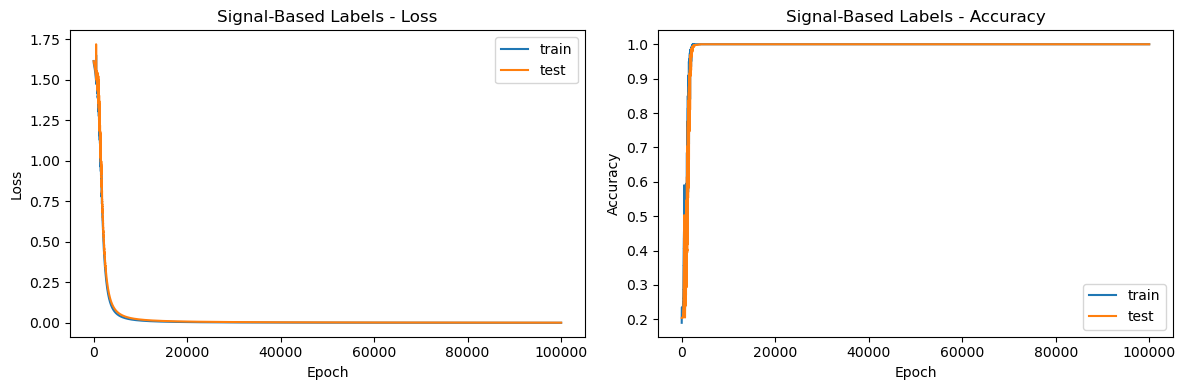

In [29]:
model_signal = SingleLayerCNNGAP(
    m=DATA_CONFIG['m'],
    K=MODEL_CONFIG['K'],
    num_classes=DATA_CONFIG['c'],
)

metrics_signal = train_model(
    model=model_signal,
    X_train=X_train_signal,
    y_train=y_train_signal,
    X_test=X_test_signal,
    y_test=y_test_signal,
    epochs=10 * TRAIN_CONFIG['epochs'],
    lr=MODEL_CONFIG['lr'] + 0.2,
    weight_decay=TRAIN_CONFIG['weight_decay'],
    grad_clip=TRAIN_CONFIG['grad_clip'],
    print_every=TRAIN_CONFIG['print_every'],
)

plot_metrics(metrics_signal, title='Signal-Based Labels', show_test=True)


## 6. Experiment B: Random Labels

We train on random labels and only report **training** loss/accuracy.


Epoch    1 | Train loss 1.6169, acc 0.225
Epoch  100 | Train loss 1.5991, acc 0.230
Epoch  200 | Train loss 1.5972, acc 0.265
Epoch  300 | Train loss 1.5952, acc 0.295
Epoch  400 | Train loss 1.5932, acc 0.295
Epoch  500 | Train loss 1.5911, acc 0.290
Epoch  600 | Train loss 1.5889, acc 0.300
Epoch  700 | Train loss 1.5865, acc 0.305
Epoch  800 | Train loss 1.5840, acc 0.300
Epoch  900 | Train loss 1.5814, acc 0.295
Epoch 1000 | Train loss 1.5787, acc 0.300
Epoch 1100 | Train loss 1.5758, acc 0.300
Epoch 1200 | Train loss 1.5727, acc 0.300
Epoch 1300 | Train loss 1.5747, acc 0.235
Epoch 1400 | Train loss 1.5751, acc 0.235
Epoch 1500 | Train loss 1.5735, acc 0.245
Epoch 1600 | Train loss 1.5714, acc 0.255
Epoch 1700 | Train loss 1.5692, acc 0.260
Epoch 1800 | Train loss 1.5669, acc 0.270
Epoch 1900 | Train loss 1.5648, acc 0.285
Epoch 2000 | Train loss 1.5625, acc 0.295
Epoch 2100 | Train loss 1.5601, acc 0.295
Epoch 2200 | Train loss 1.5628, acc 0.280
Epoch 2300 | Train loss 1.5554, ac

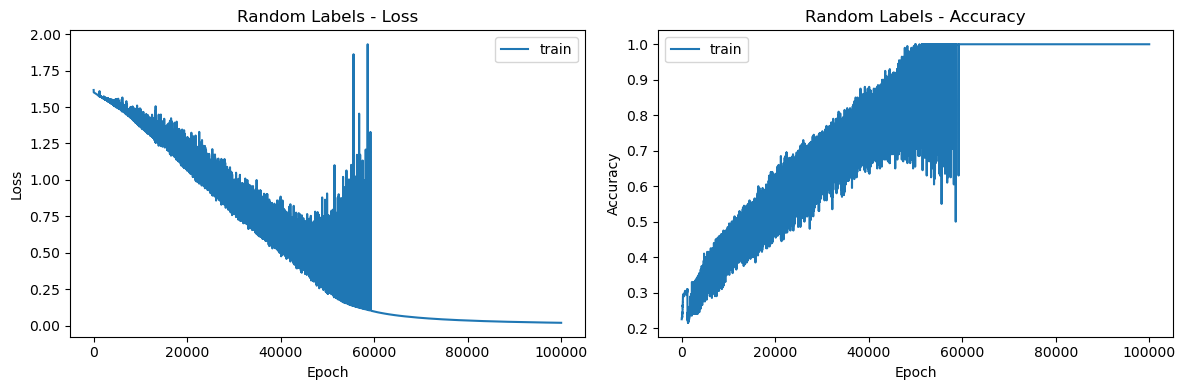

In [15]:
model_random = SingleLayerCNNGAP(
    m=DATA_CONFIG['m'],
    K=MODEL_CONFIG['K'],
    num_classes=DATA_CONFIG['c'],
)

metrics_random = train_model(
    model=model_random,
    X_train=X_train_random,
    y_train=y_train_random,
    X_test=None,
    y_test=None,
    epochs=10 * TRAIN_CONFIG['epochs'],
    lr=MODEL_CONFIG['lr'] + 0.2,
    weight_decay=TRAIN_CONFIG['weight_decay'],
    grad_clip=TRAIN_CONFIG['grad_clip'],
    print_every=TRAIN_CONFIG['print_every'],
)

plot_metrics(metrics_random, title='Random Labels', show_test=False)


In [32]:
def compute_filter_pathnorm(model: nn.Module) -> float:
    """
    Compute sum_k ||v_k|| * ||w_k||, where:
      - w_k is the k-th filter in patch_linear (length m)
      - v_k is the classifier weight vector for filter k across classes
    """
    with torch.no_grad():
        # patch_linear: (K, m), classifier: (c, K)
        w = model.patch_linear.weight  # (K, m)
        v = model.classifier.weight  # (c, K)
        w_norms = torch.norm(w, dim=1)  # (K,)
        v_norms = torch.norm(v, dim=0)  # (K,)
        return torch.sum(w_norms * v_norms).item()


pathnorm_signal = compute_filter_pathnorm(model_signal)
pathnorm_random = compute_filter_pathnorm(model_random)

print(f"Filter pathnorm sum (signal labels): {pathnorm_signal:.6f}")
print(f"Filter pathnorm sum (random labels): {pathnorm_random:.6f}")


Filter pathnorm sum (signal labels): 2724.226074
Filter pathnorm sum (random labels): 16024.314453


## 7. Representation Learning Analysis (Signal-Based Labels)

We analyze learned representations for the signal-based dataset.

**We skip label-output alignment analysis** as requested.

We focus on:
- **GMM clustering** on the raw patch space
- **PCA and LDA** on CNN patch features, colored by the discovered clusters
- **Filter Fisher selectivity**, measuring how well each filter separates clusters


Fitting GMM with 6 components...
GMM clustering complete.
Cluster distribution:
  Cluster 0: 3693 patches (36.93%)
  Cluster 1: 37 patches (0.37%)
  Cluster 2: 126 patches (1.26%)
  Cluster 3: 1853 patches (18.53%)
  Cluster 4: 4254 patches (42.54%)
  Cluster 5: 37 patches (0.37%)

Performing PCA on CNN patch features...
PCA explained variance ratio: [0.4060434  0.15737168]
PCA cumulative variance: 0.5634

Performing LDA on CNN patch features...
LDA explained variance ratio: [0.5354661  0.25020593]
LDA cumulative variance: 0.7857

Visualizing CNN patch feature space...


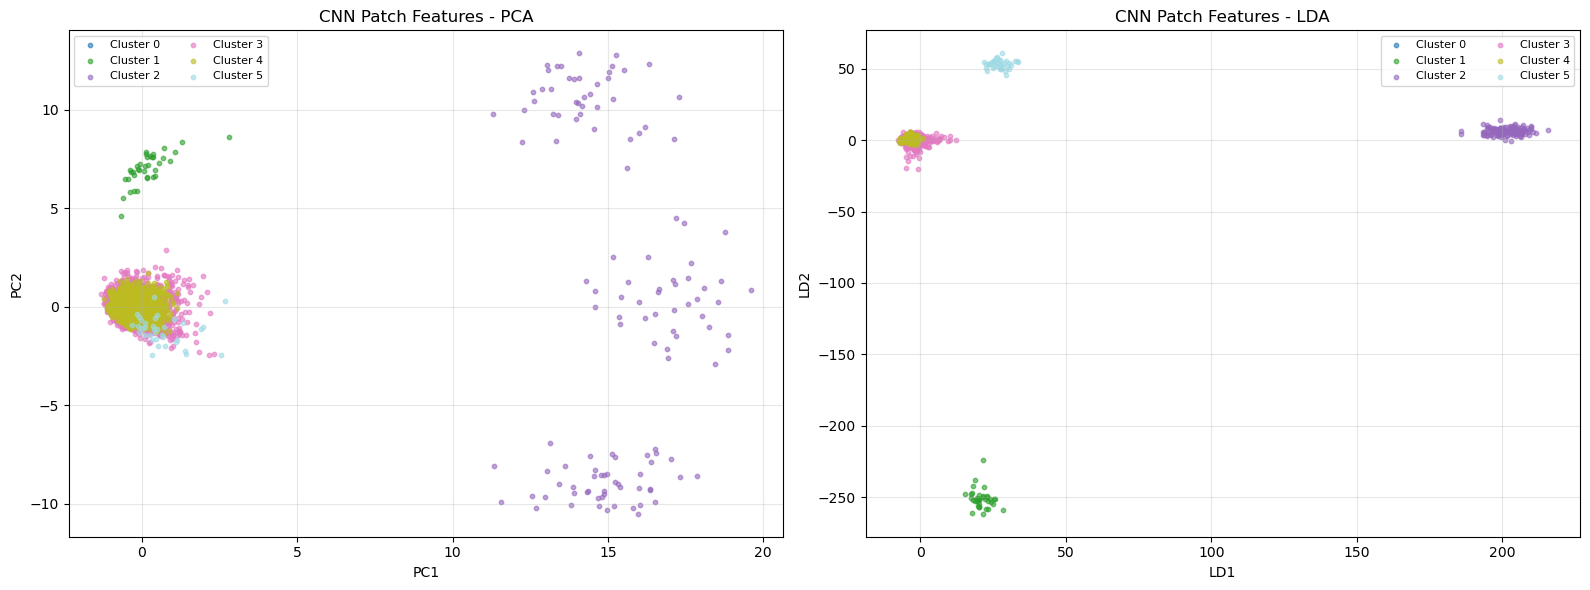


Computing Fisher selectivity for all filters...
Top 10 filters by Fisher selectivity:
   1. Filter 308: Fisher score = 38.2574
   2. Filter 305: Fisher score = 33.3048
   3. Filter 90: Fisher score = 31.7993
   4. Filter 355: Fisher score = 25.8700
   5. Filter 43: Fisher score = 24.8102
   6. Filter 15: Fisher score = 24.7033
   7. Filter 21: Fisher score = 24.6872
   8. Filter 235: Fisher score = 24.4691
   9. Filter 190: Fisher score = 23.1342
  10. Filter 251: Fisher score = 23.0688

Mean Fisher score: 3.2047
Max Fisher score:  38.2574


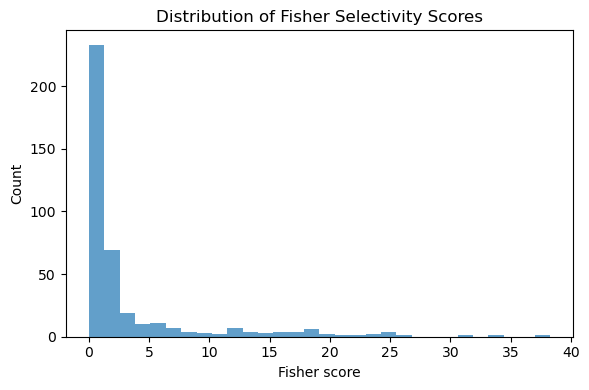

In [ ]:
# ---------------------------------------------------------------------
# 7.1 GMM Clustering on Raw Patch Space
# ---------------------------------------------------------------------
# Flatten patches: (n_samples, J, m) -> (n_samples * J, m)
X_train_signal_np = X_train_signal.cpu().numpy()
all_patches = X_train_signal_np.reshape(-1, DATA_CONFIG['m'])

N_CLUSTERS = DATA_CONFIG['c'] + 1  # feature clusters + noise cluster
print(f"Fitting GMM with {N_CLUSTERS} components...")

gmm = GaussianMixture(
    n_components=N_CLUSTERS,
    covariance_type='full',
    max_iter=600,
    n_init=6,
    random_state=4,
)

gmm.fit(all_patches)
cluster_labels_train = gmm.predict(all_patches)

unique_clusters, cluster_counts = np.unique(cluster_labels_train, return_counts=True)
print("GMM clustering complete.")
print("Cluster distribution:")
for cid, cnt in zip(unique_clusters, cluster_counts):
    pct = 100.0 * cnt / len(cluster_labels_train)
    print(f"  Cluster {cid}: {cnt} patches ({pct:.2f}%)")

# ---------------------------------------------------------------------
# 7.2 CNN Patch Features + PCA/LDA
# ---------------------------------------------------------------------
# Extract CNN patch features from the trained signal-based model
model_signal.eval()
with torch.no_grad():
    _, patch_features, _ = model_signal(X_train_signal.to(device))

patch_features_np = patch_features.cpu().numpy()  # (n, J, K)
cnn_features_train = patch_features_np.reshape(-1, patch_features_np.shape[-1])  # (n*J, K)

# PCA on CNN features
print("\nPerforming PCA on CNN patch features...")
pca = PCA(n_components=2)
cnn_features_pca = pca.fit_transform(cnn_features_train)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"PCA cumulative variance: {pca.explained_variance_ratio_.sum():.4f}")

# LDA on CNN features using cluster labels
print("\nPerforming LDA on CNN patch features...")
cluster_counts_dict = dict(zip(*np.unique(cluster_labels_train, return_counts=True)))
valid_cluster_mask = np.array([cluster_counts_dict[label] >= 2 for label in cluster_labels_train])

cnn_features_lda = None
if valid_cluster_mask.sum() > 0 and len(np.unique(cluster_labels_train[valid_cluster_mask])) > 1:
    lda = LinearDiscriminantAnalysis(n_components=2)
    cnn_features_lda = lda.fit_transform(
        cnn_features_train[valid_cluster_mask],
        cluster_labels_train[valid_cluster_mask],
    )
    print(f"LDA explained variance ratio: {lda.explained_variance_ratio_}")
    print(f"LDA cumulative variance: {lda.explained_variance_ratio_.sum():.4f}")
else:
    print("Warning: Not enough samples per cluster for LDA")


def plot_feature_space(features_pca, features_lda, cluster_labels, valid_mask=None):
    """Plot PCA and LDA projections colored by cluster assignments."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))

    # PCA plot
    ax = axes[0]
    for i, cluster_id in enumerate(unique_clusters):
        mask = cluster_labels == cluster_id
        ax.scatter(
            features_pca[mask, 0],
            features_pca[mask, 1],
            c=[colors[i]],
            label=f"Cluster {cluster_id}",
            alpha=0.6,
            s=10,
        )
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title("CNN Patch Features - PCA")
    ax.grid(True, alpha=0.3)
    if n_clusters <= 20:
        ax.legend(fontsize=8, loc="best", ncol=2)

    # LDA plot
    if features_lda is not None:
        ax = axes[1]
        if valid_mask is not None:
            plot_labels = cluster_labels[valid_mask]
            unique_clusters_lda = np.unique(plot_labels)
        else:
            plot_labels = cluster_labels
            unique_clusters_lda = unique_clusters

        for cluster_id in unique_clusters_lda:
            mask = plot_labels == cluster_id
            cluster_idx = np.where(unique_clusters == cluster_id)[0][0]
            ax.scatter(
                features_lda[mask, 0],
                features_lda[mask, 1],
                c=[colors[cluster_idx]],
                label=f"Cluster {cluster_id}",
                alpha=0.6,
                s=10,
            )
        ax.set_xlabel("LD1")
        ax.set_ylabel("LD2")
        ax.set_title("CNN Patch Features - LDA")
        ax.grid(True, alpha=0.3)
        if len(unique_clusters_lda) <= 20:
            ax.legend(fontsize=8, loc="best", ncol=2)
    else:
        axes[1].text(0.5, 0.5, "LDA not available",
                     ha="center", va="center", transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()


print("\nVisualizing CNN patch feature space...")
plot_feature_space(cnn_features_pca, cnn_features_lda, cluster_labels_train, valid_cluster_mask)

# ---------------------------------------------------------------------
# 7.3 Filter Fisher Selectivity
# ---------------------------------------------------------------------

def compute_fisher_selectivity(features: np.ndarray, cluster_labels: np.ndarray) -> np.ndarray:
    """
    Compute Fisher selectivity for each filter dimension.

    Fisher ratio = between-cluster variance / within-cluster variance.
    """
    K = features.shape[1]
    unique_clusters = np.unique(cluster_labels)

    # Overall mean
    overall_mean = features.mean(axis=0)

    # Between-cluster variance
    between_var = np.zeros(K)
    for cluster_id in unique_clusters:
        mask = cluster_labels == cluster_id
        cluster_mean = features[mask].mean(axis=0)
        n_k = mask.sum()
        between_var += n_k * (cluster_mean - overall_mean) ** 2
    between_var /= features.shape[0]

    # Within-cluster variance
    within_var = np.zeros(K)
    for cluster_id in unique_clusters:
        mask = cluster_labels == cluster_id
        cluster_features = features[mask]
        cluster_mean = cluster_features.mean(axis=0)
        within_var += ((cluster_features - cluster_mean) ** 2).sum(axis=0)
    within_var /= features.shape[0]

    # Fisher ratio
    fisher_scores = between_var / (within_var + 1e-10)
    return fisher_scores


print("\nComputing Fisher selectivity for all filters...")
fisher_scores = compute_fisher_selectivity(cnn_features_train, cluster_labels_train)

# Report top filters
sorted_idx = np.argsort(fisher_scores)[::-1]
print("Top 10 filters by Fisher selectivity:")
for rank, idx in enumerate(sorted_idx[:10], start=1):
    print(f"  {rank:2d}. Filter {idx}: Fisher score = {fisher_scores[idx]:.4f}")

print(f"\nMean Fisher score: {fisher_scores.mean():.4f}")
print(f"Max Fisher score:  {fisher_scores.max():.4f}")

plt.figure(figsize=(6, 4))
plt.hist(fisher_scores, bins=30, alpha=0.7)
plt.title("Distribution of Fisher Selectivity Scores")
plt.xlabel("Fisher score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
